In [1]:
import mne
import importlib
from funtions import segment_signal, EEGDataset, EEGMeModel, train_loso
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:

base_path = r"/home/neuro-admin/Documents/projects/Sofia/Datos"

all_data = []
all_labels = []
all_subjects = []

window_size = 1000  #superponer
step = 500

for subject_id, subject in enumerate(os.listdir(base_path)):
    subject_path = os.path.join(base_path, subject)

    if not os.path.isdir(subject_path):
        continue

    # Definir los sujetos
    if "GU" in subject:
        label = 1
    elif "GG" in subject:
        label = 0
    else:
        print(f"Sujeto desconocido: {subject}")
        continue

    print(f"Sujeto: {subject}, Label: {label}")

    for root, dirs, files in os.walk(subject_path):
        for file in files:
            if file.endswith(".fif") and "DTAN" in file:
                if file.endswith(".fif") and "desc-Muscle" in file:
                    file_path = os.path.join(root, file)
                    print(f"  Leyendo: {file}")
                    raw = mne.io.read_raw_fif(file_path, preload=True)
                    raw.pick_types(eeg=True)

    

                    eeg = raw.get_data().astype(np.float32)  # (C, T)
                    eeg = (eeg - np.mean(eeg, axis=1, keepdims=True)) / \
                    (np.std(eeg, axis=1, keepdims=True) + 1e-8)
                    segments = segment_signal(eeg, window_size, step)

                    for seg in segments:
                        all_data.append(seg)
                        all_labels.append(label)
                        all_subjects.append(subject_id)

Sujeto: sub-GU027, Label: 1
  Leyendo: sub-GU027_ses-V0_task-DTAN_desc-Muscle_sm0.7_ct0.2_fb0.05_eeg.fif
Opening raw data file /home/neuro-admin/Documents/projects/Sofia/Datos/sub-GU027/ses-V0/eeg/sub-GU027_ses-V0_task-DTAN_desc-Muscle_sm0.7_ct0.2_fb0.05_eeg.fif...
    Range : 0 ... 11249 =      0.000 ...    44.996 secs
Ready.
Reading 0 ... 11249  =      0.000 ...    44.996 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Sujeto: sub-GG004, Label: 0
Sujeto: sub-GU022, Label: 1
  Leyendo: sub-GU022_ses-V0_task-DTAN_desc-Muscle_sm0.7_ct0.2_fb0.05_eeg.fif
Opening raw data file /home/neuro-admin/Documents/projects/Sofia/Datos/sub-GU022/ses-V0/eeg/sub-GU022_ses-V0_task-DTAN_desc-Muscle_sm0.7_ct0.2_fb0.05_eeg.fif...
    Range : 0 ... 11249 =      0.000 ...    44.996 secs
Ready.
Reading 0 ... 11249  =      0.000 ...    44.996 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Sujeto: sub-GG088, Label: 0
Sujeto: sub-GG076, L

In [3]:
print("Total segmentos:", len(all_data))
print("Total labels:", len(all_labels))
print("Total subjects:", len(all_subjects))

Total segmentos: 1445
Total labels: 1445
Total subjects: 1445


In [4]:
print("Sujetos únicos:", len(set(all_subjects)))

Sujetos únicos: 63


In [10]:
from collections import Counter

count = Counter(all_subjects)

print("Segmentos por sujeto:")
for k, v in count.items():
    print(k, v)

Segmentos por sujeto:
0 21
2 21
4 21
6 23
7 23
8 21
10 23
11 26
12 23
13 21
14 23
15 21
16 21
17 23
18 21
19 26
20 26
21 23
22 28
23 21
24 23
25 23
26 21
27 26
28 26
29 23
32 26
33 23
34 23
36 23
37 23
38 23
39 21
40 23
43 23
44 21
45 23
47 21
48 21
49 21
50 21
52 26
55 21
56 23
57 26
59 21
60 23
61 23
62 21
63 23
64 23
65 23
66 23
67 23
68 21
70 28
71 23
73 26
74 21
75 23
78 23
80 21
81 26


In [3]:
all_data = np.array(all_data)
all_labels = np.array(all_labels)
all_subjects = np.array(all_subjects)

In [4]:
models = train_loso(EEGMeModel, all_data, all_labels, all_subjects)


 Test subject: 0
Epoch 0 | Train: 0.6855 | Val: 0.8019
Epoch 1 | Train: 0.6657 | Val: 0.7717
Epoch 2 | Train: 0.6378 | Val: 0.6439
Epoch 3 | Train: 0.5965 | Val: 0.8099
Epoch 4 | Train: 0.5329 | Val: 0.8041
Epoch 5 | Train: 0.5153 | Val: 0.8129
Epoch 6 | Train: 0.4793 | Val: 0.8865
Epoch 7 | Train: 0.4630 | Val: 0.8094
Epoch 8 | Train: 0.4386 | Val: 0.9594
Epoch 9 | Train: 0.4292 | Val: 0.9529
Epoch 10 | Train: 0.4029 | Val: 0.9379
Epoch 11 | Train: 0.3872 | Val: 0.9938
Epoch 12 | Train: 0.3908 | Val: 0.9424
Epoch 13 | Train: 0.3518 | Val: 1.0006
Epoch 14 | Train: 0.3306 | Val: 1.0193
Epoch 15 | Train: 0.3294 | Val: 1.0174
Epoch 16 | Train: 0.3247 | Val: 1.0240
Epoch 17 | Train: 0.3205 | Val: 1.0334
Epoch 18 | Train: 0.3114 | Val: 1.0318
Epoch 19 | Train: 0.3090 | Val: 1.0391
Epoch 20 | Train: 0.3127 | Val: 1.0590
Epoch 21 | Train: 0.3153 | Val: 1.0681
Epoch 22 | Train: 0.3149 | Val: 1.0649
Early stopping
Sujeto 0 | Pred final: 1 | Real: 1

Subject-Level Accuracy: 1.0000

 Test subjec

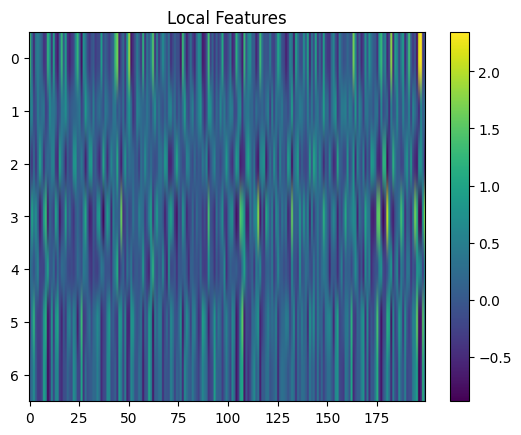

In [7]:
feat = np.load("all_local_features_71.npy")
x = feat[0]
x = x.squeeze(1)
plt.imshow(x, aspect='auto')

plt.colorbar()

plt.title("Local Features")

plt.show()

In [6]:
feat.shape

(6, 7, 1, 200)

In [8]:
x.shape

(7, 200)

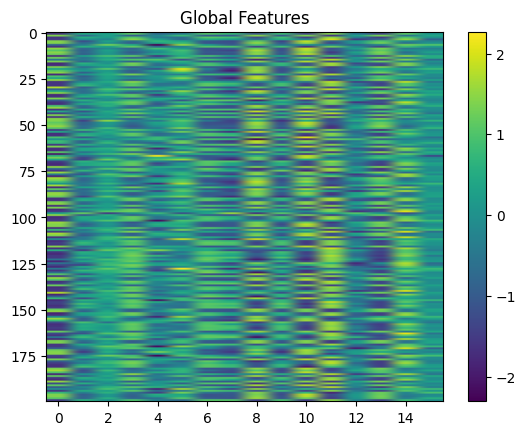

In [4]:
g = np.load("all_global_features_71.npy")
x = g[0]

plt.imshow(x, aspect='auto')

plt.colorbar()

plt.title("Global Features")

plt.show()

In [3]:
g.shape

(6, 200, 16)

In [9]:
import numpy as np
import glob

emb_files = sorted(glob.glob("embeddings_subject_*.npy"))
label_files = sorted(glob.glob("labels_subject_*.npy"))
subject_files = sorted(glob.glob("subjects_subject_*.npy"))
pred_files = sorted(glob.glob("preds_subject_*.npy"))

In [10]:
all_embeddings = []
all_labels = []
all_subjects = []
all_preds = []

for ef, lf, sf, pf in zip(
    emb_files,
    label_files,
    subject_files,
    pred_files
):

    all_embeddings.append(np.load(ef))
    all_labels.append(np.load(lf))
    all_subjects.append(np.load(sf))
    all_preds.append(np.load(pf))

all_embeddings = np.concatenate(all_embeddings, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
all_subjects = np.concatenate(all_subjects, axis=0)
all_preds = np.concatenate(all_preds, axis=0)

In [11]:
print(all_embeddings.shape)

(56, 16)


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
# t-distributed Stochastic Neighbor Embedding  ---cómo se organizan los embeddings
tsne = TSNE(
n_components=2,
perplexity=30,
learning_rate='auto',
init='pca',
random_state=42
)

emb_2d = tsne.fit_transform(all_embeddings)

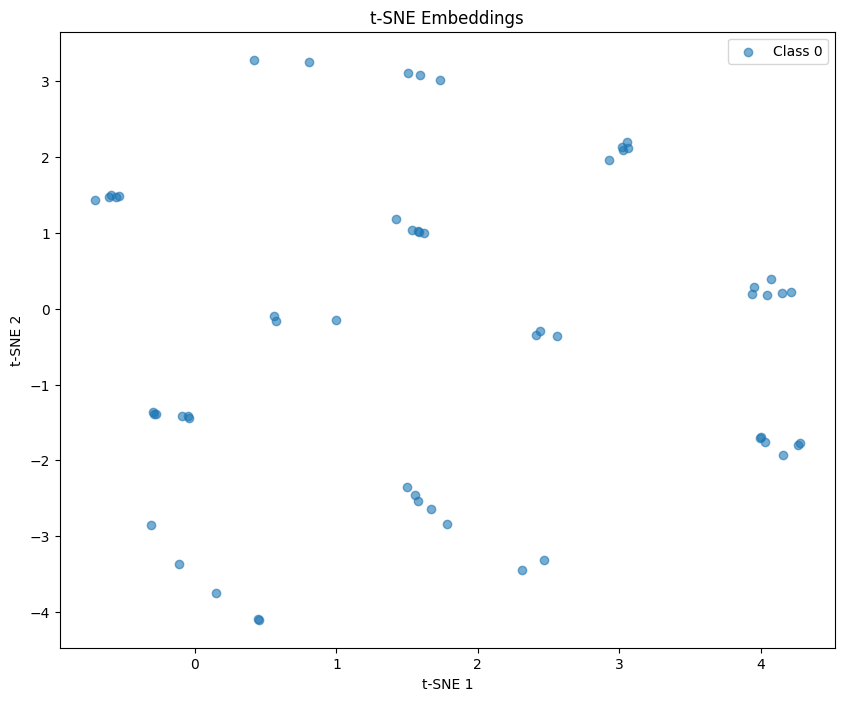

In [ ]:
# PASO 4 — visualizar por clase


plt.figure(figsize=(10,8))

for label in np.unique(all_labels):

    idx = all_labels == label

    plt.scatter(
        emb_2d[idx,0],
        emb_2d[idx,1],
        label=f'Class {label}',
        alpha=0.6
    )

plt.legend()
plt.title("t-SNE Embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.show()

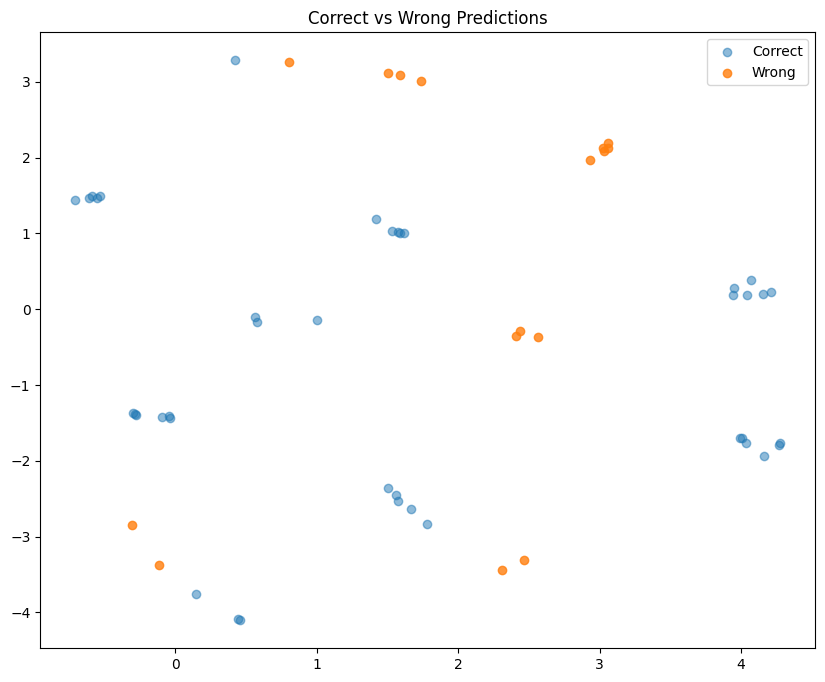

In [15]:
correct = all_labels == all_preds

plt.figure(figsize=(10,8))

plt.scatter(
    emb_2d[correct,0],
    emb_2d[correct,1],
    alpha=0.5,
    label='Correct'
)

plt.scatter(
    emb_2d[~correct,0],
    emb_2d[~correct,1],
    alpha=0.8,
    label='Wrong'
)

plt.legend()
plt.title("Correct vs Wrong Predictions")

plt.show()

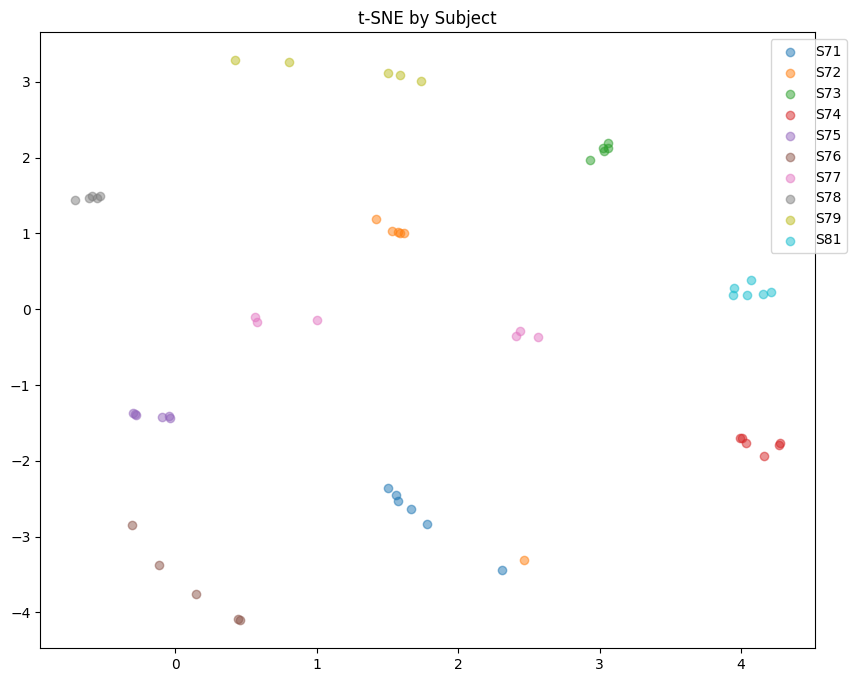

In [16]:
plt.figure(figsize=(10,8))

for subj in np.unique(all_subjects):

    idx = all_subjects == subj

    plt.scatter(
        emb_2d[idx,0],
        emb_2d[idx,1],
        label=f'S{subj}',
        alpha=0.5
    )

plt.legend(bbox_to_anchor=(1.05,1))

plt.title("t-SNE by Subject")

plt.show()

In [ ]:
# los kernels convolucionales temporales -- solo que tengo kernel de (1,10), entonces solo me cubre 0.04s, debería cambiar este
w = np.load("temporal_weights_subject_71.npy")
print(w.shape)

(7, 1, 1, 10)


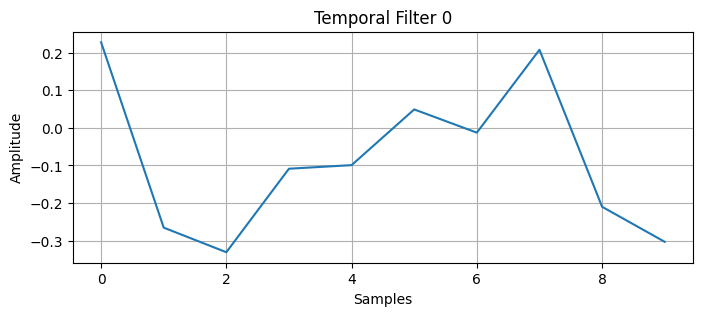

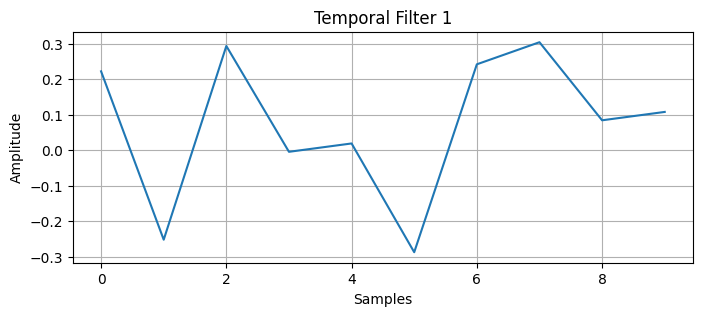

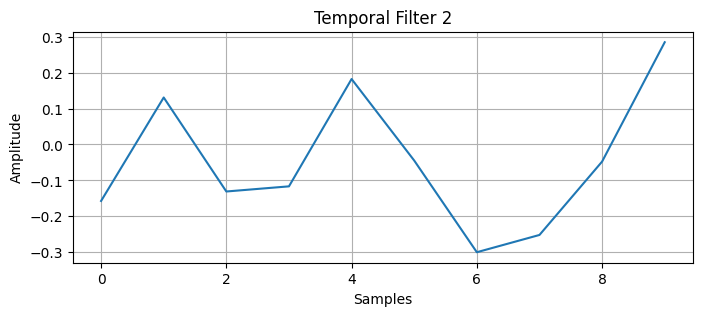

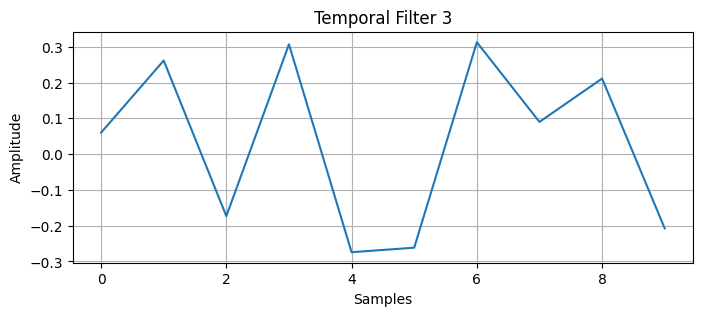

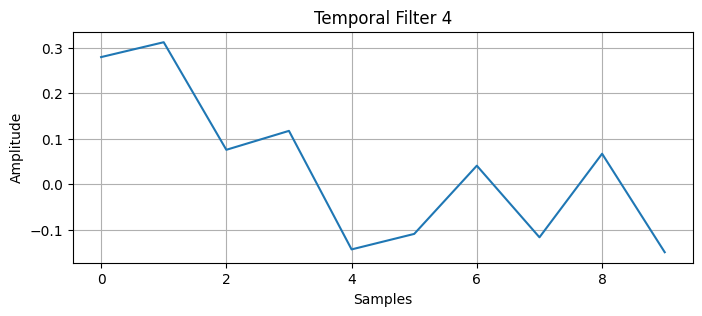

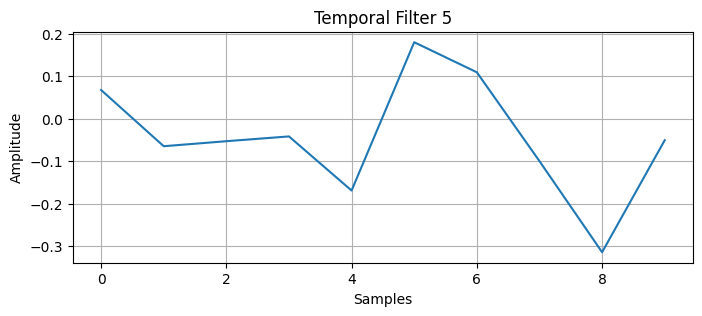

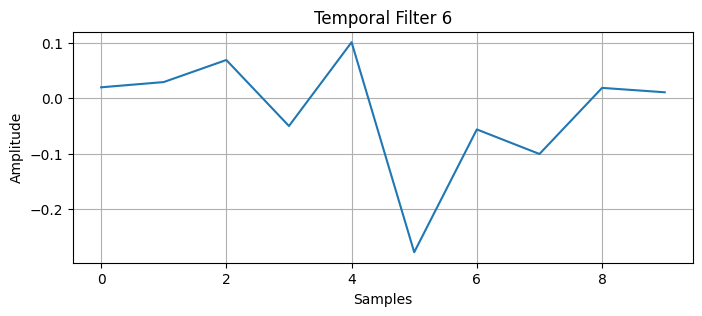

In [ ]:
for i in range(w.shape[0]):

    plt.figure(figsize=(8,3))
    plt.plot(w[i,0,0,:])
    plt.title(f"Temporal Filter {i}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

In [ ]:
#Attention maps
#Saliency maps